In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import fftconvolve
import IPython
import pyroomacoustics as pra

Для практики создаю 3D модель комнаты

(0.0, 2.0)

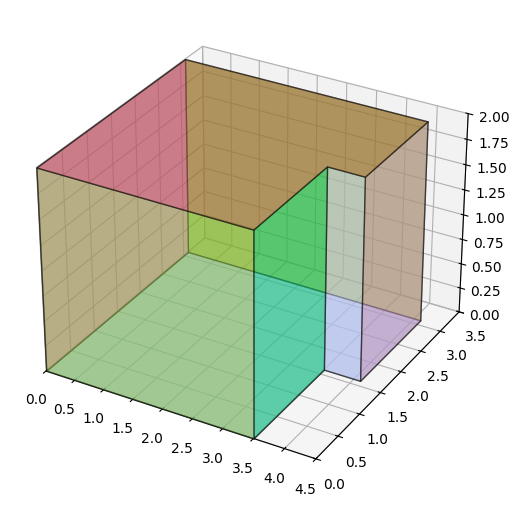

In [2]:
#Задаю ее размеры
corners = np.array([[0,0], [0, 3.1], [4.1, 3.1], [4.1, 1.6], [3.5, 1.6], [3.5, 0]]).T
room = pra.Room.from_corners(corners)
room.extrude(2)

#Устанавливаю ограничения
fig, ax = room.plot()
ax.set_xlim([0, 4.5])
ax.set_ylim([0, 3.5])
ax.set_zlim([0, 2])

Далее я буду Моделировать ситуацию в 2D пространстве.

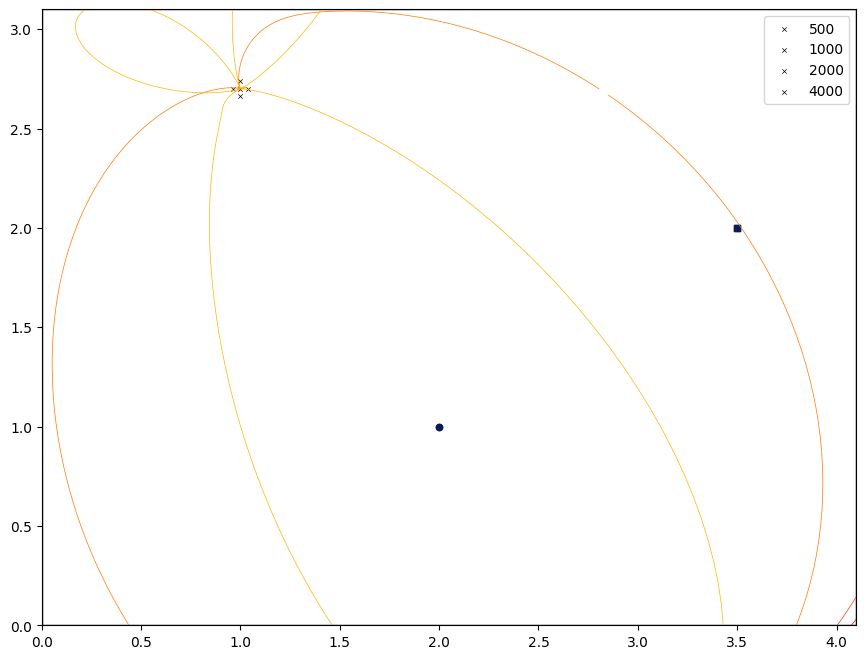

In [ ]:
# Загрузка аудиофайлов
fs, signal = wavfile.read("arctic_a0010.wav")
fs_noise, noise = wavfile.read("arctic_b0539.wav")

# Создаем комнату
room_bf = pra.ShoeBox([4.1, 3.1], fs=fs, max_order=12)

source = np.array([2, 1])
interferer = np.array([3.5, 2])
room_bf.add_source(source, delay=0, signal=signal)
room_bf.add_source(interferer, delay=0, signal=noise[:len(signal)])

# Создаем микрофонную решетку
center = [1, 2.7]
radius = 37.5e-3
echo = pra.circular_2D_array(center=center, M=4, phi0=0, radius=radius)
echo = np.concatenate((echo, np.array(center, ndmin=2).T), axis=1)

# Длина фильтра и FFT
Lg = np.ceil(0.1 * fs)
fft_len = 512

mics = pra.Beamformer(echo, room_bf.fs, N=fft_len, Lg=Lg)
room_bf.add_microphone_array(mics)

mics.rake_delay_and_sum_weights(room_bf.sources[0][:1])

room_bf.simulate()

fig, ax = room_bf.plot(freq=[500, 1000, 2000, 4000], img_order=0)
ax.legend(['500', '1000', '2000', '4000'])
fig.set_size_inches(20, 8)

Преобразуем полученные данные с помощью STFT

In [ ]:
X = pra.transform.stft.analysis(room_bf.mic_array.signals.T, fft_len, fft_len // 2)
X = X.transpose(2, 0, 1) 

time_idx = 1
freq_idx = 2
X_freq = X[:, time_idx, freq_idx].reshape(-1, 1) 

После подготовки данных, реализуем алгоритм ESPRIT

In [8]:
def ESPRIT(signal_matrix, num_source=1):
    
    M,t = signal_matrix.shape

    x = signal_matrix @ signal_matrix.conj().T/t  #ковариац матрица
    _, y = np.linalg.eigh(x) #раскладываю по собю значениям
    Ys = y[:,:-num_source] #выделяю подпространство

    
    Ys1 = Ys[:-1, :]
    Ys2 = Ys[1:, :]

    a = np.linalg.pinv(Ys1) @ Ys2 #обобщённое собственное уравнение

    eigvals = np.linalg.eigvals(a)  #собсственная матрица
    angle = np.angle(eigvals)  #собственные значения

    return np.degrees(angle)

angles = ESPRIT(X_freq)
print(angles)

[  63.14477645  -52.1304703   160.48276852 -139.30664167]


Визуализируем полученный результат

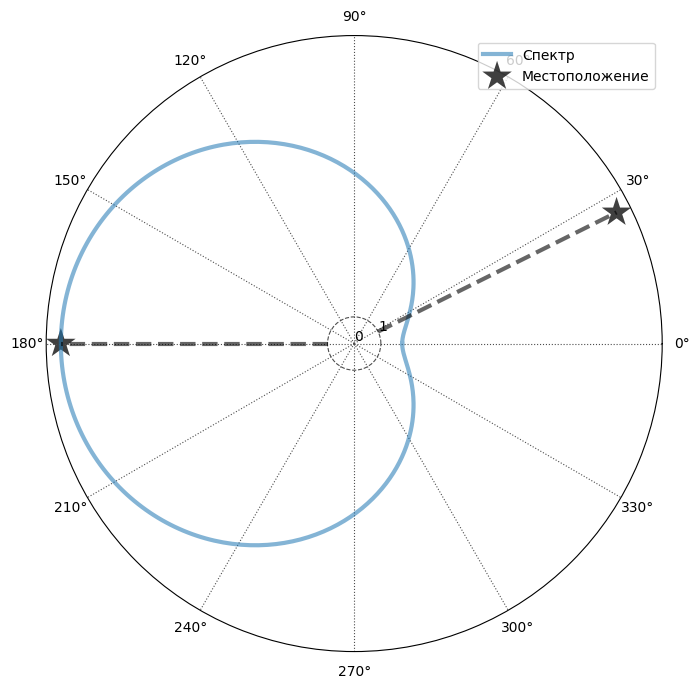

In [9]:
base = 1.
height = 10.
true_col = [0, 0, 0]
num_angles = 360
phi_plt = np.linspace(0, 2 * np.pi, num_angles)

true_azimuth = np.arctan2(1.0, 2.0)  
azimuth = np.array([true_azimuth, np.pi]) 

dirty_img = np.zeros(num_angles)
for angle in angles:
    idx = np.argmin(np.abs(phi_plt - angle))
    dirty_img[idx] = 1.0 

dirty_img = np.roll(np.hamming(num_angles), np.argmax(dirty_img)) 

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')

c_phi_plt = np.r_[phi_plt, phi_plt[0]]
c_dirty_img = np.r_[dirty_img, dirty_img[0]]
ax.plot(c_phi_plt, base + height * c_dirty_img, linewidth=3, alpha=0.55, linestyle='-', label="Спектр")

for angle in azimuth:
    ax.plot([angle, angle], [base, base + height], linewidth=3, linestyle='--', color=true_col, alpha=0.6)

K = len(azimuth)
ax.scatter(azimuth, base + height * np.ones(K), c=np.tile(true_col, (K, 1)), s=500,
           alpha=0.75, marker='*', linewidths=0, label='Местоположение')

plt.legend()
ax.set_xticks(np.linspace(0, 2 * np.pi, num=12, endpoint=False))
ax.set_yticks(np.linspace(0, 1, 2))
ax.xaxis.grid(True, color=[0.3, 0.3, 0.3], linestyle=':')
ax.yaxis.grid(True, color=[0.3, 0.3, 0.3], linestyle='--')
ax.set_ylim([0, 1.05 * (base + height)])
ax.legend(loc="upper right")

plt.show()